## Cross-validation

Used to estimate how accurately a predictive model will perform in practice.

In [8]:
import sys
print(sys.executable)

# general python modules for scientific analysis
import sys, pathlib, os, itertools, os
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

sys.path.append('../../src')
from sklearn.model_selection import train_test_split
from physion.analysis.read_NWB import Data
from physion.analysis.dataframe import NWB_to_dataframe, extract_stim_keys
from physion.utils import plot_tools as pt

sys.path.append('../../src/physion/analysis')
from cross_validation import TwoFold_train_test_split

C:\Users\laura.gonzalez\AppData\Local\miniforge3\python.exe


In [9]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','NDNF-WT-Dec-2022','NWBs')
filename = os.path.join(datafolder, '2022_12_14-13-27-41.nwb') #for example
data = Data(filename)
df = NWB_to_dataframe(filename,
                      normalize=['dFoF', 'Pupil-diameter', 'Running-Speed', 'Whisking'],
                      visual_stim_label='per-protocol-and-parameters',
                      verbose=False)

NWB-file reading time: 903.8ms


{'spont_train_sets': [array([ 9619,  9620,  9621, ..., 18443, 18444, 18445]), array([18446, 18447, 18448, ..., 27270, 27271, 27272])], 'spont_test_sets': [array([18446, 18447, 18448, ..., 27270, 27271, 27272]), array([ 9619,  9620,  9621, ..., 18443, 18444, 18445])], 'stim_train_sets': [array([    0,     1,     2, ..., 38605, 38606, 38607]), array([38608, 38609, 38610, ..., 59559, 59560, 59561])], 'stim_test_sets': [array([38608, 38609, 38610, ..., 59559, 59560, 59561]), array([    0,     1,     2, ..., 38605, 38606, 38607])]}


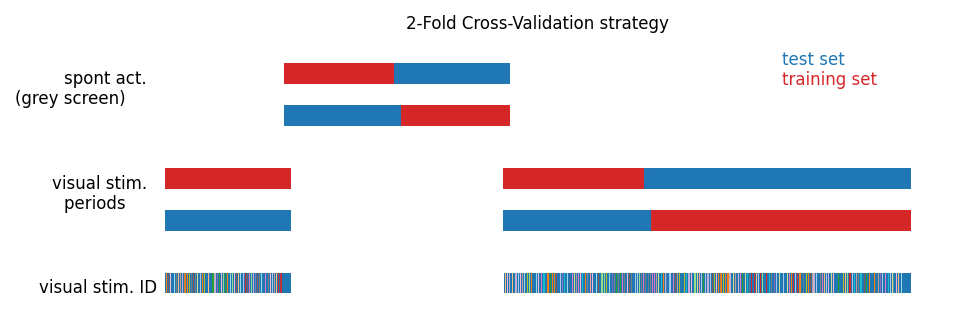

In [7]:
cvIndices = TwoFold_train_test_split(df, spont_act_key='VisStim_grey-10min')
print(cvIndices)

# Plot
fig, ax = plt.subplots(figsize=(7,2))
ii = 10

for train, test in zip(cvIndices['spont_train_sets'], cvIndices['spont_test_sets']):
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=10)
    ax.scatter(df['time'][test], ii+0.5+np.zeros(len(df['time'][test])), c='tab:blue', marker="_", lw=10)
    ii-=2
ax.annotate('spont act.    \n(grey screen)        ', (0, ii+3), ha='right')
ii-=1


for train, test in zip(cvIndices['stim_train_sets'], cvIndices['stim_test_sets']):
    ax.scatter(df['time'][train], ii+0.5+np.zeros(len(df['time'][train])), c='tab:red', marker="_", lw=10)
    ax.scatter(df['time'][test], ii+0.5+np.zeros(len(df['time'][test])), c='tab:blue', marker="_", lw=10)
    ii-=2
ax.annotate('visual stim.    \nperiods        ', (0, ii+3), ha='right')

stim_keys = [k for k in df if ('VisStim' in k)]
stimID = 0*df['time']
stim_cond = (~df['VisStim_grey-10min'])
for i, k in enumerate(stim_keys):
        stimID[df[k]] = i+1
    
ax.scatter(
    df['time'][stim_cond], [ii-0.5] * np.sum(stim_cond), c=stimID[stim_cond], marker="_", lw=10, 
    cmap=plt.cm.tab20)
ax.annotate('visual stim. ID  ', (0, ii-1), ha='right')


ax.annotate('training set', (.8,.9), color='tab:red', xycoords='axes fraction')
ax.annotate('test set\n', (.8,.9), color='tab:blue', xycoords='axes fraction')

ax.axis('off')
ax.set_xlabel("time (s)")
ax.set_title('2-Fold Cross-Validation strategy\n ')
ax.axes.get_xaxis().set_visible(True)

To do: 
- Have the same number of episodes in training and test sets
- Have the same proportion of active vs quiet state in training and tests sets
- Shuffle visual stimulation
  